In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# Download latest version
path = kagglehub.competition_download('shl-hiring-assessment-2026')

print("Path to competition files:", path)

/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_81.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final

In [2]:
!pip install -q git+https://github.com/openai/whisper.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [8]:
import torch

dataset_base = os.path.join(path, "Dataset_Final")

CONFIG = {
    "train_audio_dir": os.path.join(dataset_base, "train"),
    "test_audio_dir": os.path.join(dataset_base, "test"),
    "train_csv": os.path.join(dataset_base, "train.csv"),
    "test_csv": os.path.join(dataset_base, "test.csv"),
    "sample_submission": os.path.join(dataset_base, "sample_submission.csv"),
    "whisper_model": "small",      
    "deberta_model": "microsoft/deberta-v3-large",
    "random_state": 42
}

device = "cuda" if torch.cuda.is_available() else "cpu"

In [16]:
import pandas as pd
import numpy as np
import whisper
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore", message="FP16 is not supported on CPU")

train_df = pd.read_csv(CONFIG["train_csv"])
test_df = pd.read_csv(CONFIG["test_csv"])

if len(train_df.columns) == 2:
    train_df.columns = ['filename', 'score']

if len(test_df.columns) == 1:
    test_df.columns = ['filename']
elif len(test_df.columns) == 2:
    test_df.columns = ['filename', 'dummy_score']

asr_model = whisper.load_model(CONFIG["whisper_model"], device=device)
error_preserving_prompt = "Umm, let me see. Me is going to the stores. Transcribe exactly with mistakes."

def transcribe_audio_dir(df, audio_dir):
    transcriptions = []
    for filename in tqdm(df['filename'], desc=f"Transcribing {os.path.basename(audio_dir)}"):
        if not str(filename).endswith('.wav'):
            filename = f"{filename}.wav"
        filepath = os.path.join(audio_dir, filename)
        if os.path.exists(filepath):
            result = asr_model.transcribe(
                filepath,
                initial_prompt=error_preserving_prompt,
                temperature=0.0
            )
            transcriptions.append(result["text"].strip())
        else:
            transcriptions.append("")
    return transcriptions

train_df['text'] = transcribe_audio_dir(train_df, CONFIG["train_audio_dir"])
test_df['text'] = transcribe_audio_dir(test_df, CONFIG["test_audio_dir"])

display(train_df.head(3))

Transcribing test: 100%|██████████| 216/216 [08:17<00:00,  2.30s/it]


,filename,score,text
0,audio_192.wav,3.0,"Umm, well the playground is very, very beautif..."
1,audio_436.wav,3.0,The scene of a school playground. Our playgrou...
2,audio_447.wav,3.5,My favorite place to visit is the beach. I lov...


In [17]:
import librosa

def extract_acoustic_prosody(df, audio_dir):
    features = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Acoustic extraction: {os.path.basename(audio_dir)}"):
        filename = row['filename']
        text = str(row['text'])
        if not str(filename).endswith('.wav'):
            filename = f"{filename}.wav"
        filepath = os.path.join(audio_dir, filename)

        if not os.path.exists(filepath):
            features.append([0.0] * 8)
            continue

        y_audio, sr = librosa.load(filepath, sr=16000)
        total_duration = librosa.get_duration(y=y_audio, sr=sr)
        if total_duration == 0:
            features.append([0.0] * 8)
            continue

        rmse = librosa.feature.rms(y=y_audio, frame_length=1024, hop_length=512)[0]
        threshold = np.percentile(rmse, 25)
        silent_frames = rmse < max(threshold, 0.005)
        silence_ratio = float(np.mean(silent_frames))

        frame_time = 512 / sr
        pauses = []
        cur_p = 0
        for is_silent in silent_frames:
            if is_silent:
                cur_p += frame_time
            else:
                if cur_p >= 0.4:
                    pauses.append(cur_p)
                cur_p = 0
        if cur_p >= 0.4:
            pauses.append(cur_p)

        pause_count = len(pauses)
        mean_pause = float(np.mean(pauses)) if pause_count > 0 else 0.0

        f0 = librosa.yin(y_audio, fmin=65, fmax=300, sr=sr)
        f0_clean = f0[~np.isnan(f0)]
        f0_mean = float(np.mean(f0_clean)) if len(f0_clean) > 0 else 0.0
        f0_std = float(np.std(f0_clean)) if len(f0_clean) > 0 else 0.0

        word_count = len(text.split())
        wpm = (word_count / total_duration) * 60.0 if total_duration > 0 else 0.0
        active_speech_time = total_duration * (1.0 - silence_ratio)
        art_rate = (word_count / active_speech_time) if active_speech_time > 0 else 0.0

        features.append([
            total_duration,
            silence_ratio,
            pause_count,
            mean_pause,
            f0_mean,
            f0_std,
            wpm,
            art_rate
        ])

    cols = ['total_dur', 'silence_ratio', 'pause_cnt', 'mean_pause', 'f0_mean', 'f0_std', 'wpm', 'art_rate']
    return pd.DataFrame(features, columns=cols)

acoustic_train = extract_acoustic_prosody(train_df, CONFIG["train_audio_dir"])
acoustic_test = extract_acoustic_prosody(test_df, CONFIG["test_audio_dir"])

display(acoustic_train.head(3))

Acoustic extraction: test: 100%|██████████| 216/216 [00:24<00:00,  8.81it/s]


,total_dur,silence_ratio,pause_cnt,mean_pause,f0_mean,f0_std,wpm,art_rate
0,60.508375,0.445796,18,1.246222,154.063427,43.724569,96.185032,2.892587
1,60.074688,0.250266,7,0.758857,211.235888,56.698988,109.863243,2.442272
2,60.074688,0.250266,9,0.832000,149.851821,57.353164,143.820973,3.197157


In [18]:
import re

def extract_lexical_syntactic(df):
    records = []
    for text in df['text']:
        text = str(text).strip()
        words = re.findall(r'\b\w+\b', text.lower())
        total_words = len(words)

        if total_words == 0:
            records.append([0.0] * 6)
            continue

        unique_words = len(set(words))
        ttr = unique_words / total_words

        avg_word_len = float(np.mean([len(w) for w in words]))
        sentences = [s for s in re.split(r'[.!?]+', text) if s.strip()]
        sentence_count = max(1, len(sentences))
        avg_sentence_len = total_words / sentence_count

        punc_count = len(re.findall(r'[,.!?]', text))
        punc_ratio = punc_count / total_words
        char_count = len(text)

        records.append([
            total_words,
            ttr,
            avg_word_len,
            avg_sentence_len,
            punc_ratio,
            char_count
        ])

    cols = ['total_words', 'ttr', 'avg_word_len', 'avg_sent_len', 'punc_ratio', 'char_count']
    return pd.DataFrame(records, columns=cols)

lex_train = extract_lexical_syntactic(train_df)
lex_test = extract_lexical_syntactic(test_df)

display(lex_train.head(3))

,total_words,ttr,avg_word_len,avg_sent_len,punc_ratio,char_count
0,103.0,0.601942,3.854369,10.300000,0.194175,519.0
1,110.0,0.463636,4.381818,18.333333,0.063636,598.0
2,144.0,0.520833,3.951389,13.090909,0.097222,726.0


In [19]:
from transformers import AutoTokenizer, AutoModel

def extract_mean_pooled_deberta(train_texts, test_texts):
    tokenizer = AutoTokenizer.from_pretrained(CONFIG["deberta_model"])
    model = AutoModel.from_pretrained(CONFIG["deberta_model"]).to(device)
    model.eval()

    def pool(texts):
        pooled = []
        with torch.no_grad():
            for text in tqdm(texts, desc="Mean-Pooling DeBERTa"):
                if not text or str(text).strip() == "":
                    text = "empty"
                encoded = tokenizer(
                    text,
                    return_tensors="pt",
                    truncation=True,
                    padding=True,
                    max_length=256
                ).to(device)

                output = model(**encoded)
                last_hidden = output.last_hidden_state
                mask = encoded['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()

                sum_masked = torch.sum(last_hidden * mask, dim=1)
                mask_counts = torch.clamp(mask.sum(dim=1), min=1e-9)
                mean_vec = (sum_masked / mask_counts).squeeze(0).cpu().numpy()

                norm = np.linalg.norm(mean_vec)
                if norm > 0:
                    mean_vec = mean_vec / norm
                pooled.append(mean_vec)
        return np.array(pooled)

    return pool(train_texts), pool(test_texts)

emb_train, emb_test = extract_mean_pooled_deberta(train_df['text'].tolist(), test_df['text'].tolist())
print(f"DeBERTa Embedding Matrix Shape: {emb_train.shape}")

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Mean-Pooling DeBERTa: 100%|██████████

DeBERTa Embedding Matrix Shape: (769, 1024)


In [21]:
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from scipy.optimize import minimize
import lightgbm as lgb
import xgboost as xgb

kf = KFold(n_splits=5, shuffle=True, random_state=CONFIG["random_state"])
y = train_df['score'].values

ridge_oof = np.zeros(len(train_df))
ridge_test = np.zeros(len(test_df))

for tr_idx, va_idx in kf.split(emb_train, y):
    ridge = RidgeCV(alphas=np.logspace(-2, 4, 30))
    ridge.fit(emb_train[tr_idx], y[tr_idx])
    ridge_oof[va_idx] = ridge.predict(emb_train[va_idx])
    ridge_test += ridge.predict(emb_test) / kf.n_splits

svd = TruncatedSVD(n_components=16, random_state=CONFIG["random_state"])
svd_train = svd.fit_transform(emb_train)
svd_test = svd.transform(emb_test)

tab_train = np.hstack([
    acoustic_train.values,
    lex_train.values,
    svd_train,
    ridge_oof.reshape(-1, 1)
])

tab_test = np.hstack([
    acoustic_test.values,
    lex_test.values,
    svd_test,
    ridge_test.reshape(-1, 1)
])

lgb_oof = np.zeros(len(train_df))
lgb_test = np.zeros(len(test_df))
xgb_oof = np.zeros(len(train_df))
xgb_test = np.zeros(len(test_df))

for tr_idx, va_idx in kf.split(tab_train, y):
    X_tr, y_tr = tab_train[tr_idx], y[tr_idx]
    X_va, y_va = tab_train[va_idx], y[va_idx]

    m_lgb = lgb.LGBMRegressor(
        n_estimators=800,
        learning_rate=0.015,
        num_leaves=15,
        subsample=0.8,
        colsample_bytree=0.7,
        random_state=CONFIG["random_state"]
    )
    m_lgb.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    lgb_oof[va_idx] = m_lgb.predict(X_va)
    lgb_test += m_lgb.predict(tab_test) / kf.n_splits

    m_xgb = xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.015,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.7,
        early_stopping_rounds=50,
        objective='reg:squarederror',
        random_state=CONFIG["random_state"]
    )
    m_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    xgb_oof[va_idx] = m_xgb.predict(X_va)
    xgb_test += m_xgb.predict(tab_test) / kf.n_splits

raw_blend_oof = (0.40 * ridge_oof) + (0.35 * lgb_oof) + (0.25 * xgb_oof)
raw_blend_test = (0.40 * ridge_test) + (0.35 * lgb_test) + (0.25 * xgb_test)

def objective_fn(weights):
    a, b = weights
    pred = np.clip(a * raw_blend_oof + b, 1.0, 5.0)
    return np.sqrt(mean_squared_error(y, pred))

res = minimize(objective_fn, [1.0, 0.0], method='Powell')
a_opt, b_opt = res.x

final_oof = np.clip(a_opt * raw_blend_oof + b_opt, 1.0, 5.0)
final_test = np.clip(a_opt * raw_blend_test + b_opt, 1.0, 5.0)

print(f"Calibration Parameters: Scale={a_opt:.4f}, Shift={b_opt:.4f}")
print(f"Calibrated OOF RMSE: {np.sqrt(mean_squared_error(y, final_oof)):.4f}")
print(f"Calibrated OOF Pearson: {pearsonr(y, final_oof)[0]:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000295 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5928
[LightGBM] [Info] Number of data points in the train set: 615, number of used features: 31
[LightGBM] [Info] Start training from score 3.337398


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5927
[LightGBM] [Info] Number of data points in the train set: 615, number of used features: 31
[LightGBM] [Info] Start training from score 3.353659


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000207 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5922
[LightGBM] [Info] Number of data points in the train set: 615, number of used features: 31
[LightGBM] [Info] Start training from score 3.276423


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5922
[LightGBM] [Info] Number of data points in the train set: 615, number of used features: 31
[LightGBM] [Info] Start training from score 3.315447


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5934
[LightGBM] [Info] Number of data points in the train set: 616, number of used features: 31
[LightGBM] [Info] Start training from score 3.284091


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Calibration Parameters: Scale=1.0235, Shift=-0.0588
Calibrated OOF RMSE: 0.6840
Calibrated OOF Pearson: 0.8370


=== MANDATORY BENCHMARK METRICS ===
Training / OOF RMSE: 0.6840
Training / OOF Pearson Correlation: 0.8370


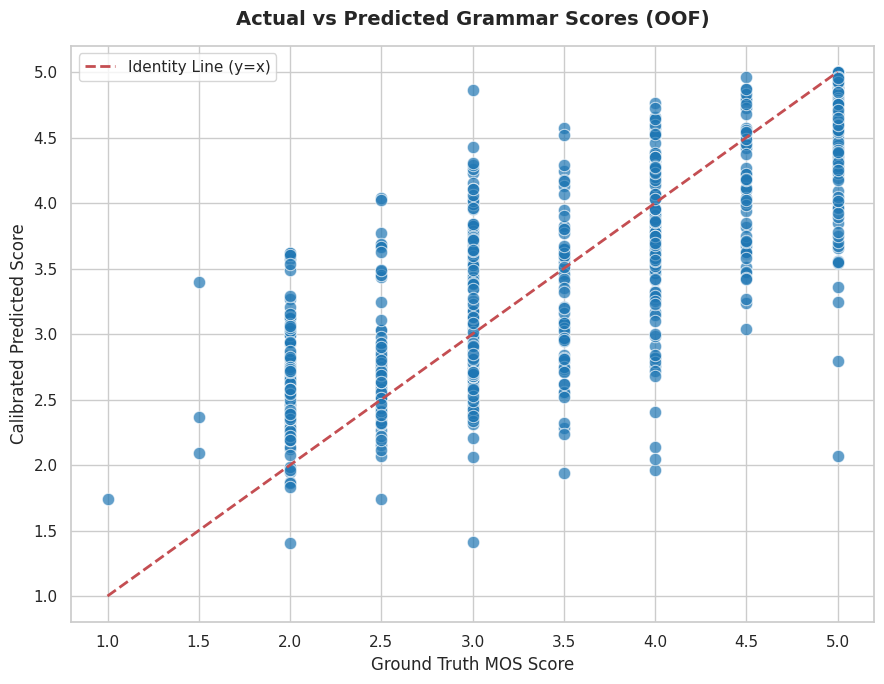

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

rmse_train = np.sqrt(mean_squared_error(y, final_oof))
pearson_train, _ = pearsonr(y, final_oof)

print("=== MANDATORY BENCHMARK METRICS ===")
print(f"Training / OOF RMSE: {rmse_train:.4f}")
print(f"Training / OOF Pearson Correlation: {pearson_train:.4f}")

plt.figure(figsize=(9, 7))
sns.set_theme(style="whitegrid")
sns.scatterplot(x=y, y=final_oof, alpha=0.7, color='#1f77b4', edgecolor='w', s=80)
plt.plot([1.0, 5.0], [1.0, 5.0], 'r--', lw=2, label="Identity Line (y=x)")

plt.title("Actual vs Predicted Grammar Scores (OOF)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ground Truth MOS Score", fontsize=12)
plt.ylabel("Calibrated Predicted Score", fontsize=12)
plt.xlim(0.8, 5.2)
plt.ylim(0.8, 5.2)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
sample_sub = pd.read_csv(CONFIG["sample_submission"])

submission = pd.DataFrame({
    sample_sub.columns[0]: test_df['filename'],
    sample_sub.columns[1]: final_test
})

submission_path = "/kaggle/working/submission.csv"
submission.to_csv(submission_path, index=False)

print(f"Submission generated at: {submission_path}")
display(submission.head())

Submission generated at: /kaggle/working/submission.csv


,filename,label
0,audio_128.wav,3.123667
1,audio_156.wav,4.022156
2,audio_19.wav,4.435034
3,audio_108.wav,2.334730
4,audio_206.wav,2.129002
